In [ ]:
!pip install b3alien

In [1]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import sparse
import dask.array as da
import numpy as np

from pyproj import Proj, Transformer
from shapely.geometry import mapping
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load the GRIIS checklist

checklist_path = "../data/dwca-unified-checklist-v1.15/"
distribution = checklist_path + "distribution.txt"

df_cl = pd.read_csv(distribution, sep='\t', low_memory=False)

print('test')

test


In [3]:
# Specific issue due to the Belgian checklist
df_cl["speciesKey"] = df_cl["id"].str.rsplit("/", n=1).str[-1].astype("int64")

In [4]:
df_cl.head()

,id,locationID,locality,countryCode,occurrenceStatus,establishmentMeans,degreeOfEstablishment,pathway,eventDate,source,speciesKey
0,https://www.gbif.org/species/1002621,ISO_3166:BE,Belgium,BE,present,introduced,NaN,NaN,1974/1974,https://www.gbif.org/species/157131084: Kerate...,1002621
1,https://www.gbif.org/species/1003567,ISO_3166:BE,Belgium,BE,present,introduced,NaN,NaN,2014/2022,https://www.gbif.org/species/206111211: Pectin...,1003567
2,https://www.gbif.org/species/1003567,ISO_3166:BE-VLG,Flemish Region,BE,present,introduced,NaN,NaN,2014/2022,https://www.gbif.org/species/206111211: Pectin...,1003567
3,https://www.gbif.org/species/10071055,ISO_3166:BE,Belgium,BE,present,introduced,casual,horticulture,1934/2018,https://www.gbif.org/species/141265441: Sorbus...,10071055
4,https://www.gbif.org/species/10071055,ISO_3166:BE-BRU,Brussels-Capital Region,BE,present,introduced,NaN,NaN,NaN,https://www.gbif.org/species/141265441: Sorbus...,10071055


In [5]:
# 1. Filter rows where locality == 'Flemish Region' and eventDate is not missing
df = df_cl[df_cl["locality"] == "Flemish Region"].copy()
df = df[df["eventDate"].notna()]

# 2. Split eventDate into intro and outro (assuming 'YYYY/MM' or 'YYYY/MM/YYYY/MM')
def split_event_date(x):
    if isinstance(x, str):
        parts = x.strip().split('/')
        if len(parts) == 2:
            intro = parts[0]
            outro = parts[1]
        else:
            intro = outro = np.nan
        return pd.Series([intro, outro])
    else:
        return pd.Series([np.nan, np.nan])

df[["introDate", "outroDate"]] = df["eventDate"].apply(split_event_date)

df["introDate"] = pd.to_datetime(df["introDate"], format="%Y", errors="coerce")
df["outroDate"] = pd.to_datetime(df["outroDate"], format="%Y", errors="coerce")


# 3. Clean rows with missing introDate
df_intro = df.dropna(subset=["introDate"]).copy()

# 4. Group by introDate and count species
in_species = (
    df_intro.groupby("introDate", sort=True)["id"]
    .count()
    .reset_index(name="nspec")
)

# 5. Cumulative sum
in_species["cumn"] = in_species["nspec"].cumsum()

# 6. Clean outro side and count outgoing species
df_outro = df.dropna(subset=["outroDate"]).copy()

out_species = (
    df_outro.groupby("outroDate", sort=True)["id"]
    .count()
    .reset_index(name="nspeco")
)

# 7. Merge intro and outro on date
n_species = pd.merge(in_species, out_species, how="outer", left_on="introDate", right_on="outroDate")

# 8. Replace NaNs with 0
n_species["nspec"] = n_species["nspec"].fillna(0).astype(int)
n_species["nspeco"] = n_species["nspeco"].fillna(0).astype(int)

# 9. Net species present at each time step
n_species["total"] = n_species["nspec"] - n_species["nspeco"]

# 10. Final frame with total species over time
tot_species = n_species[["introDate", "total"]].copy()

# 11. Optional: sort and compute cumulative total over time
tot_species = tot_species.sort_values("introDate")
tot_species["cumulative_total"] = tot_species["total"].cumsum()

In [6]:
in_species

,introDate,nspec,cumn
0,1700-01-01,2,2
1,1711-01-01,1,3
2,1730-01-01,1,4
3,1792-01-01,1,5
4,1827-01-01,1,6
...,...,...,...
153,2021-01-01,98,2155
154,2022-01-01,57,2212
155,2023-01-01,48,2260
156,2024-01-01,2,2262


In [7]:
#save the table
in_species.to_csv("./output/total_newly_established_species_per_year_raw_data.csv", index=False)

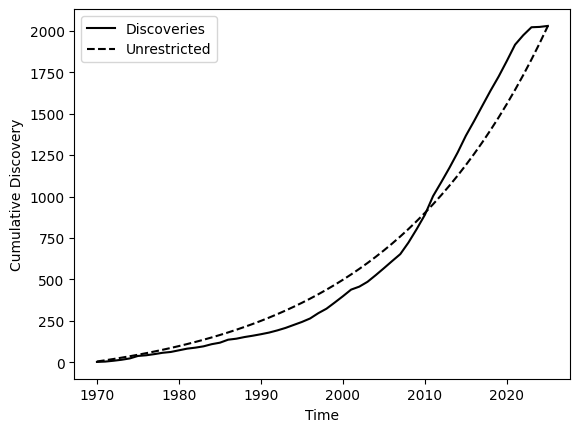

In [8]:
from b3alien import b3cube
from b3alien import griis
from b3alien import simulation

%matplotlib inline

def filter_time_window(df, start_year, end_year):
    """Filter time and rate based on year window."""
    filtered = df[(df["year"] >= start_year) & (df["year"] <= end_year)].reset_index(drop=True)
    return filtered["year"], filtered["rate"]


in_species["time"] = pd.to_datetime(in_species["introDate"])
in_species["cumulative_species"] = in_species["cumn"]

time, rate = b3cube.calculate_rate(in_species)


df = pd.DataFrame({
    "year": time,
    "rate": rate
})


# Here you can change the time period of the calculation
time, rate = filter_time_window(df, 1970, 2025)

C1, vec1 = simulation.simulate_solow_costello_scipy(time, rate, vis=True)

Bootstrapping: 100%|██████████| 10/10 [00:03<00:00,  3.14it/s]


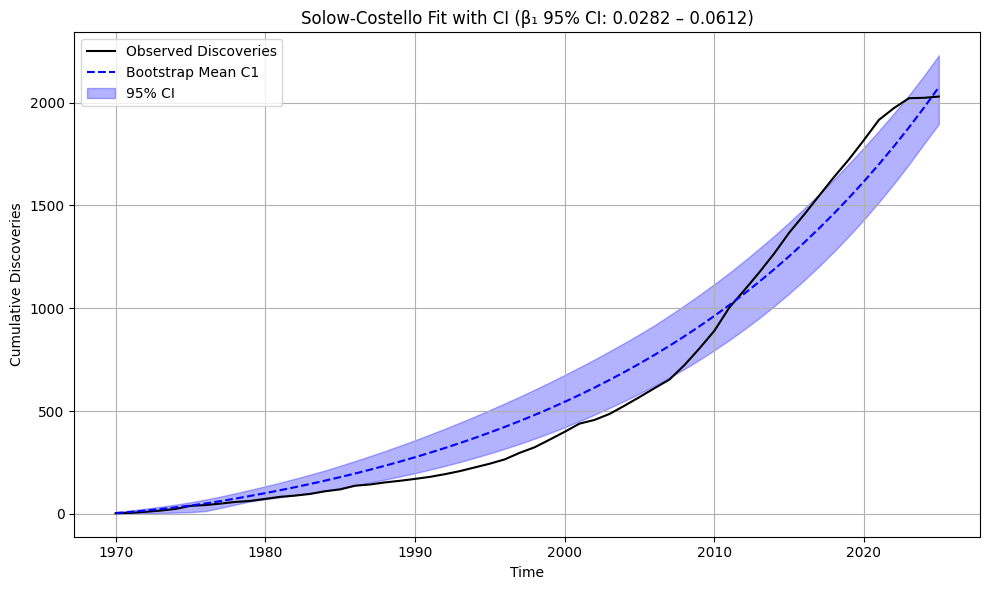

In [9]:
results = simulation.parallel_bootstrap_solow_costello(time, rate, n_iterations=10)

simulation.plot_with_confidence(time, rate, results)



In [10]:
rates_results = simulation.run_bootstrap_analysis(time, rate, n_iterations=200)

Starting 200 bootstrap iterations...

FITTING PARAMETERS RESULTS
Parameter vec1[1]: 0.048409 ± 0.015072



In [11]:
rates_results.tail()

,Year,Annual_Rate,Annual_Rate_Error,Cumulative_Value,Cumulative_Error,Lower_CI_95,Upper_CI_95
51,2021,84.001468,10.011323,1669.881179,211.756527,64.379275,103.623662
52,2022,88.190925,11.357789,1758.072104,211.738691,65.929659,110.452191
53,2023,92.538557,12.877892,1850.610661,211.728099,67.297890,117.779224
54,2024,97.121475,14.583015,1947.732136,211.945911,68.538765,125.704185
55,2025,101.871230,16.476930,2049.603366,212.527476,69.576448,134.166013


In [12]:
rates_results.to_csv("./output/estimated_rates_solow_costello_effective_annual_rates_starting_1700.csv", index=False)

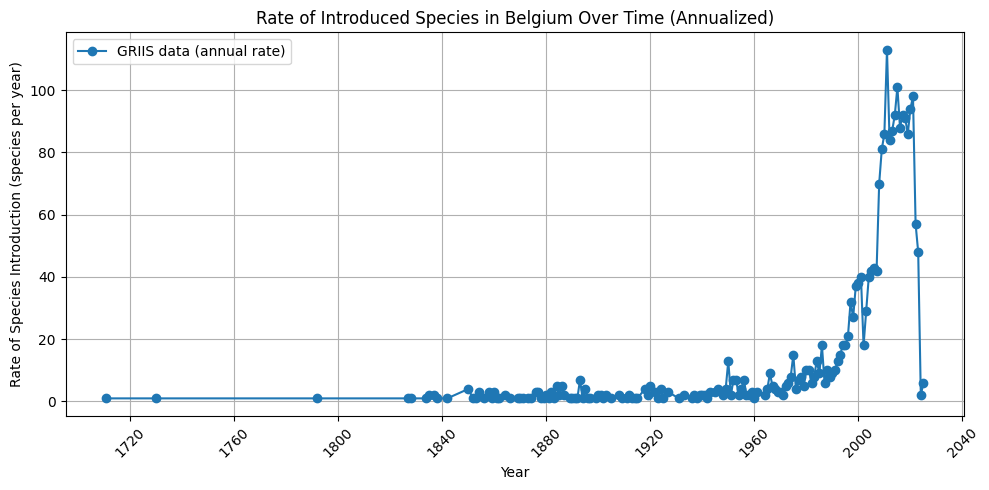

In [13]:
# --- Processing GRIIS data (Annual) ---
in_species["introDate"] = pd.to_datetime(in_species["introDate"])
in_species_rate = in_species.sort_values(by="introDate").copy()
in_species_rate["rate_per_year"] = in_species_rate["cumn"].diff()


# --- Plotting the rate of species (per year) ---
plt.figure(figsize=(10, 5))
#plt.plot(pd.to_datetime(annual_time_gbif, format='%Y'), annual_rate_gbif_series, marker="x", label="GBIF data (approx. annual rate)")
plt.plot(in_species_rate["introDate"][1:], in_species_rate["rate_per_year"][1:], marker="o", label="GRIIS data (annual rate)")
plt.title("Rate of Introduced Species in Belgium Over Time (Annualized)")
plt.xlabel("Year")
plt.ylabel("Rate of Species Introduction (species per year)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig("./output/Raw_data_new_species_per_year_figure.png")